## Diabetes Prediction Model

## Importing Modules

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Reading the Data

In [70]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

## Basic Information

In [71]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [72]:
df.shape

(100000, 9)

## Checking Null values

In [73]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


## Checking all the unique values and the Range of Values

In [75]:
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

<Axes: xlabel='age'>

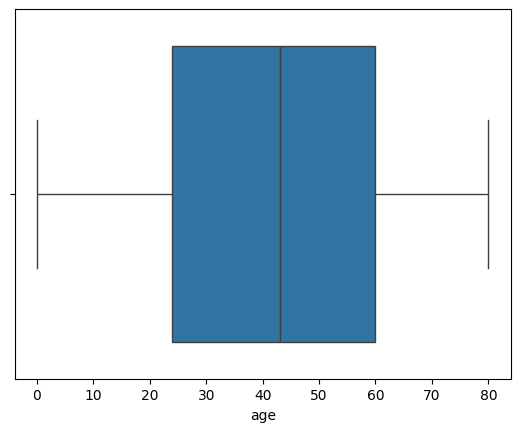

In [76]:
sns.boxplot(x = df['age'])

In [77]:
df['age'].unique()

array([80.  , 54.  , 28.  , 36.  , 76.  , 20.  , 44.  , 79.  , 42.  ,
       32.  , 53.  , 78.  , 67.  , 15.  , 37.  , 40.  ,  5.  , 69.  ,
       72.  ,  4.  , 30.  , 45.  , 43.  , 50.  , 41.  , 26.  , 34.  ,
       73.  , 77.  , 66.  , 29.  , 60.  , 38.  ,  3.  , 57.  , 74.  ,
       19.  , 46.  , 21.  , 59.  , 27.  , 13.  , 56.  ,  2.  ,  7.  ,
       11.  ,  6.  , 55.  ,  9.  , 62.  , 47.  , 12.  , 68.  , 75.  ,
       22.  , 58.  , 18.  , 24.  , 17.  , 25.  ,  0.08, 33.  , 16.  ,
       61.  , 31.  ,  8.  , 49.  , 39.  , 65.  , 14.  , 70.  ,  0.56,
       48.  , 51.  , 71.  ,  0.88, 64.  , 63.  , 52.  ,  0.16, 10.  ,
       35.  , 23.  ,  0.64,  1.16,  1.64,  0.72,  1.88,  1.32,  0.8 ,
        1.24,  1.  ,  1.8 ,  0.48,  1.56,  1.08,  0.24,  1.4 ,  0.4 ,
        0.32,  1.72,  1.48])

In [78]:
df['hypertension'].unique()

array([0, 1])

In [79]:
df['heart_disease'].unique()

array([1, 0])

In [80]:
df['HbA1c_level'].unique()

array([6.6, 5.7, 5. , 4.8, 6.5, 6.1, 6. , 5.8, 3.5, 6.2, 4. , 4.5, 9. ,
       7. , 8.8, 8.2, 7.5, 6.8])

In [81]:
df['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [82]:
df['blood_glucose_level'].unique()

array([140,  80, 158, 155,  85, 200, 145, 100, 130, 160, 126, 159,  90,
       260, 220, 300, 280, 240])

In [83]:
df['diabetes'].unique()

array([0, 1])

<Axes: xlabel='bmi'>

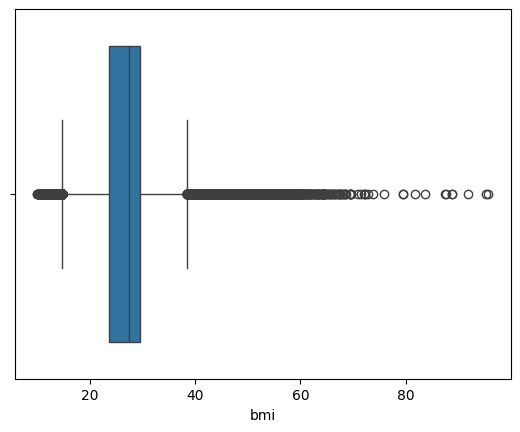

In [84]:
sns.boxplot(x=df['bmi'])

## Feature Extraction

In [85]:
df['cardio_risk'] = df['hypertension'] + df['heart_disease']

In [86]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,cardio_risk
0,Female,80.0,0,1,never,25.19,6.6,140,0,1
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,0
2,Male,28.0,0,0,never,27.32,5.7,158,0,0
3,Female,36.0,0,0,current,23.45,5.0,155,0,0
4,Male,76.0,1,1,current,20.14,4.8,155,0,2


In [87]:
df['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [88]:
df['smoking_history']  = df['smoking_history'].replace({
    "never" : 0,
    "former" : 1,
    "not current" : 2,
    "current" :3,
    "ever" : 4,
    "No Info" : 5
})

In [89]:

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,cardio_risk
0,Female,80.0,0,1,0,25.19,6.6,140,0,1
1,Female,54.0,0,0,5,27.32,6.6,80,0,0
2,Male,28.0,0,0,0,27.32,5.7,158,0,0
3,Female,36.0,0,0,3,23.45,5.0,155,0,0
4,Male,76.0,1,1,3,20.14,4.8,155,0,2


In [90]:
df = pd.get_dummies(df,"gender")

In [91]:
df = df.astype(int)

In [92]:
df

,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,cardio_risk,gender_Female,gender_Male,gender_Other
0,80,0,1,0,25,6,140,0,1,1,0,0
1,54,0,0,5,27,6,80,0,0,1,0,0
2,28,0,0,0,27,5,158,0,0,0,1,0
3,36,0,0,3,23,5,155,0,0,1,0,0
4,76,1,1,3,20,4,155,0,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,80,0,0,5,27,6,90,0,0,1,0,0
99996,2,0,0,5,17,6,100,0,0,1,0,0
99997,66,0,0,1,27,5,155,0,0,0,1,0
99998,24,0,0,0,35,4,100,0,0,1,0,0


## Separate the input and output variables

In [93]:
x = df.drop("diabetes",axis=1)
y=df['diabetes']

## Train - Test - Split

In [94]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Standard Scaling

In [95]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [96]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training

### For modeling training for selecting best parameters for model training to make model predict with high accuracy.So I have selected RamdomizedCV from Hyper Parameter Tuning

In [97]:
from sklearn.model_selection import  RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

### Logistic Regression

In [98]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=300, n_jobs=-1)
param_dist_lr = {'C': [1]}
random_search_lr = RandomizedSearchCV(
    log_reg, param_distributions=param_dist_lr,
    n_iter=1, cv=2, scoring='accuracy', n_jobs=-1, random_state=42
)
random_search_lr.fit(X_train, y_train)
y_pred_lr = random_search_lr.predict(X_test)
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.87      0.59      0.70      1708

    accuracy                           0.96     20000
   macro avg       0.92      0.79      0.84     20000
weighted avg       0.95      0.96      0.95     20000



### SVM

In [99]:
from sklearn.svm import SVC

svm = SVC(probability=True)
param_dist_svm = {'C': [1], 'kernel': ['linear']}
random_search_svm = RandomizedSearchCV(
    svm, param_distributions=param_dist_svm,
    n_iter=1, cv=2, scoring='accuracy', n_jobs=-1, random_state=42
)
# Train only on a subset to reduce runtime
random_search_svm.fit(X_train[:20000], y_train[:20000])
y_pred_svm = random_search_svm.predict(X_test)
print("SVM")
print(classification_report(y_test, y_pred_svm))

SVM
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18292
           1       0.93      0.56      0.70      1708

    accuracy                           0.96     20000
   macro avg       0.94      0.78      0.84     20000
weighted avg       0.96      0.96      0.95     20000



### Random Forest

In [100]:

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_dist_rf = {
    'n_estimators': [100],      
    'max_depth': [None, 10],    
    'min_samples_split': [2],   
    'min_samples_leaf': [1]     
}

random_search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=1,       
    cv=2,           
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search_rf.fit(X_train, y_train)

y_pred_rf = random_search_rf.predict(X_test)

print("Random Forest")
print("Best Params:", random_search_rf.best_params_)
print(classification_report(y_test, y_pred_rf))


Random Forest
Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       1.00      0.62      0.77      1708

    accuracy                           0.97     20000
   macro avg       0.98      0.81      0.87     20000
weighted avg       0.97      0.97      0.96     20000



### XGBoost

In [101]:
xgb_clf = xgb.XGBClassifier(
    use_label_encoder=False, eval_metric='logloss',
    n_jobs=-1, n_estimators=500, learning_rate=0.1, max_depth=3
)
xgb_clf.fit(X_train, y_train, eval_set=[(X_test, y_test)],  verbose=False)
y_pred_xgb = xgb_clf.predict(X_test)
print("XGBoost")
print(classification_report(y_test, y_pred_xgb))


XGBoost
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.97      0.64      0.77      1708

    accuracy                           0.97     20000
   macro avg       0.97      0.82      0.88     20000
weighted avg       0.97      0.97      0.96     20000



## XGBoost gives the best Accuracy for prediction of Diabetes Disease Prediction

In [103]:
import joblib
joblib.dump(xgb_clf,"diabetes_model.pkl")
joblib.dump(scaler , "scaler.pkl")

['scaler.pkl']